# Key questions:

1) if you have a dataset, how do you know if it’s suitable for clustering (e.g., if you data is uniformly distributed, it’s not good),

2) after you’ve run some clustering algorithm (k-mean), how to internally evaluate it (silhouette score or using a validation set for example), then

3) after they have a metric, how do they use it to choose the suitable parameters (e.g., number of clusters, eps as in dbscan, etc…)

In [1]:
import numpy as np
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import accuracy_score, silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

import time

## Part 1. Clustering Review



a. Clustering: dividing data subjects into clusters so that data subjects are similar with each other in the same cluster, and dissimilar to the subjects in different clusters.

b. Unlike classification, clustering is unsupervised learning. We have no training data.

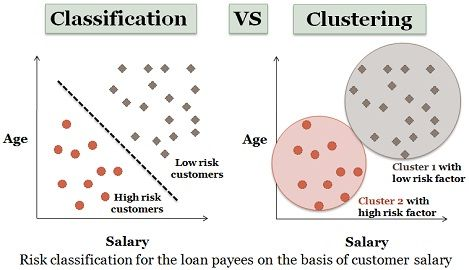

### When to use clustering

You can use a variety of techniques such as visualizing the data in a variety of ways to look for patterns.

#### Question: Which of the following datasets are suitable for clustering?

<!-- The first one -->

<Axes: >

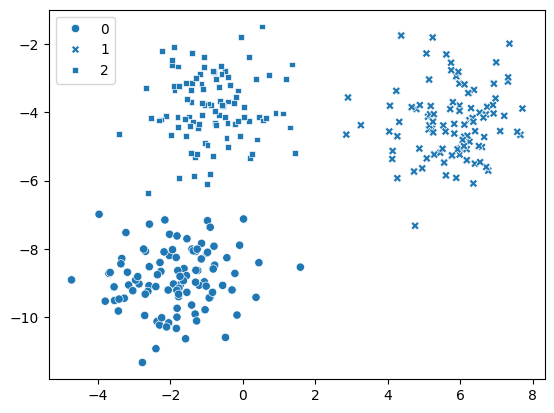

In [2]:
X1, y1_true = make_blobs(n_samples=300, centers=3,
                       cluster_std=1.0, random_state=40)
# plt.scatter(X1[:, 0], X1[:, 1], s=50, marker='x');
sns.scatterplot(x=X1[:, 0], y=X1[:, 1], style=y1_true)

<Axes: >

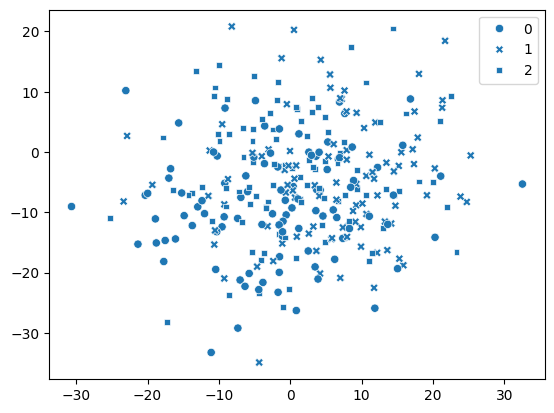

In [3]:
X2, y2_true = make_blobs(n_samples=300, centers=3,
                       cluster_std=10.0, random_state=40)
# plt.scatter(X2[:, 0], X2[:, 1], s=50, marker='x');
sns.scatterplot(x=X2[:, 0], y=X2[:, 1], style=y2_true)

Let's try K-Means on them!

Text(0.5, 1.0, 'Markers indicate ground truths, colors indicate predictions')

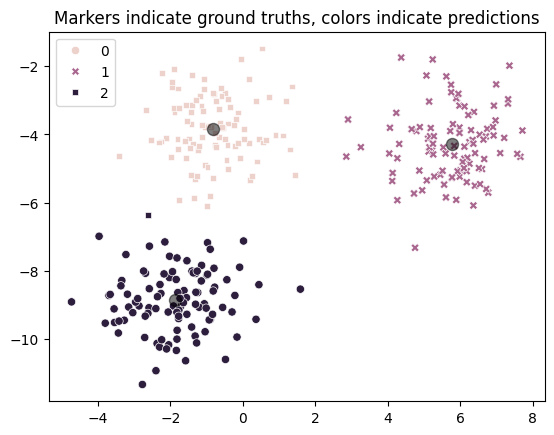

In [4]:
kmeans_sklearn = KMeans(n_clusters=3)
kmeans_sklearn.fit(X1)
y_kmeans = kmeans_sklearn.predict(X1)

# plt.scatter(X1[:, 0], X1[:, 1], c=y_kmeans, s=50, cmap='jet', marker='x')
sns.scatterplot(x=X1[:, 0], y=X1[:, 1], hue=y_kmeans, style=y1_true)
centers = kmeans_sklearn.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=75, alpha=0.5);
plt.title(label='Markers indicate ground truths, colors indicate predictions')

Text(0.5, 1.0, 'Markers indicate ground truths, colors indicate predictions')

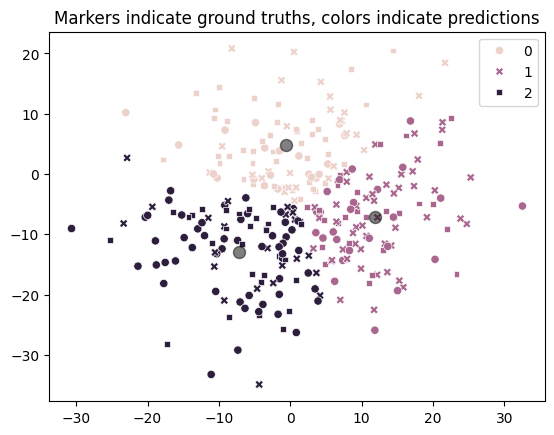

In [5]:
kmeans_sklearn = KMeans(n_clusters=3)
kmeans_sklearn.fit(X2)
y_kmeans = kmeans_sklearn.predict(X2)

# plt.scatter(X2[:, 0], X2[:, 1], c=y_kmeans, s=50, cmap='jet', marker='x')
sns.scatterplot(x=X2[:, 0], y=X2[:, 1], hue=y_kmeans, style=y2_true)
centers = kmeans_sklearn.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=75, alpha=0.5)
plt.title(label='Markers indicate ground truths, colors indicate predictions')

### Evaluation - How do I know if the results from the algorithm are good?

We can evaluate a clustering solution using metrics like **inertia** and **silhouette**.

**Inertia** is the sum of squared distances between each data point and its assigned cluster centroid.

> Inertia is a measure of how tightly grouped the data points are within each cluster.

#### Question: Do we want inertia to be high or low and why?

<!-- A **lower inertia value** indicates that the data points within a cluster are closer to their centroid, which is **desirable**. -->

The intertia of this clustering is 582.0672272472125


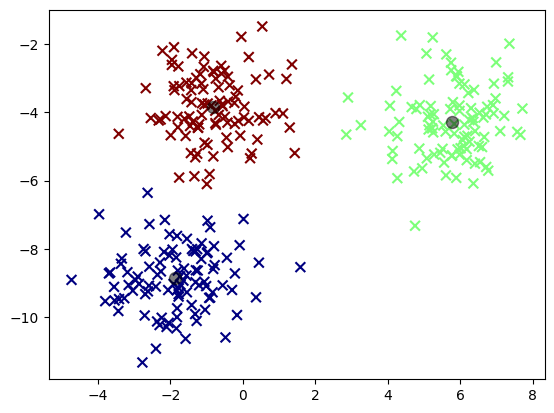

In [6]:
kmeans_sklearn = KMeans(n_clusters=3)
kmeans_sklearn.fit(X1)
y_kmeans = kmeans_sklearn.predict(X1)

plt.scatter(X1[:, 0], X1[:, 1], c=y_kmeans, s=50, cmap='jet', marker='x')
centers = kmeans_sklearn.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=75, alpha=0.5);

print("The intertia of this clustering is", kmeans_sklearn.inertia_)

The intertia of this clustering is 1898.4127128577975


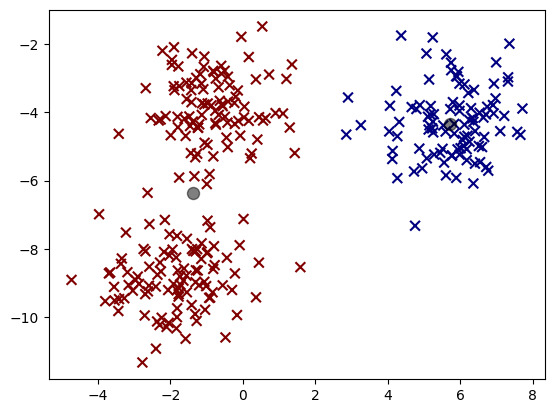

In [7]:
kmeans_sklearn = KMeans(init="random", n_clusters=2, max_iter=1)
kmeans_sklearn.fit(X1)
y_kmeans = kmeans_sklearn.predict(X1)

plt.scatter(X1[:, 0], X1[:, 1], c=y_kmeans, s=50, cmap='jet', marker='x')
centers = kmeans_sklearn.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=75, alpha=0.5);

print("The intertia of this clustering is", kmeans_sklearn.inertia_)

The intertia of this clustering is 28918.182693605813


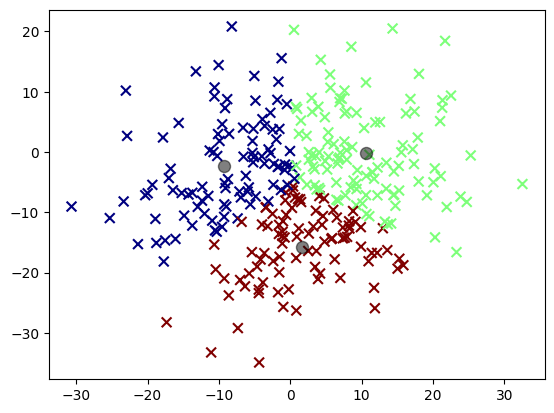

In [8]:
kmeans_sklearn = KMeans(n_clusters=3)
kmeans_sklearn.fit(X2)
y_kmeans = kmeans_sklearn.predict(X2)

plt.scatter(X2[:, 0], X2[:, 1], c=y_kmeans, s=50, cmap='jet', marker='x')
centers = kmeans_sklearn.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=75, alpha=0.5);

print("The intertia of this clustering is", kmeans_sklearn.inertia_)

But beware, inertia can be **sensitive to the number of clusters**, as increasing the number of clusters will generally reduce the inertia.
**Therefore, selecting the optimal number of clusters based on inertia alone can lead to overfitting**.

The intertia of this clustering is 270.3189555990991


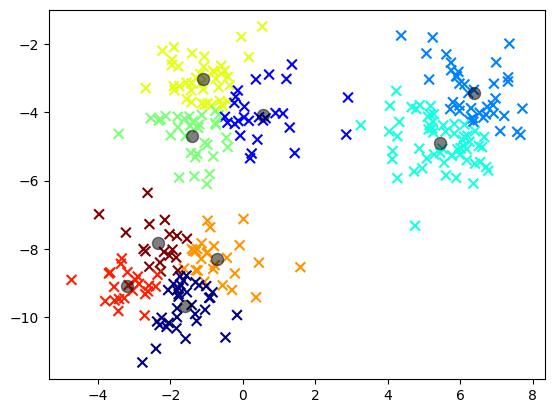

In [9]:
kmeans_sklearn = KMeans(n_clusters=9)
kmeans_sklearn.fit(X1)
y_kmeans = kmeans_sklearn.predict(X1)

plt.scatter(X1[:, 0], X1[:, 1], c=y_kmeans, s=50, cmap='jet', marker='x')
centers = kmeans_sklearn.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=75, alpha=0.5);

print("The intertia of this clustering is", kmeans_sklearn.inertia_)

**Silhouette Score**

The silhouette score is a measure of how similar a data point is to its own cluster compared to other clusters.

The silhouette score ranges from -1 to 1. A **high silhouette score** indicates that **data points are well-matched to their own cluster** and poorly matched to neighboring clusters. A negative silhouette score implies that data points might have been assigned to the wrong cluster.

The silhouette score can be **more robust than inertia** in determining the optimal number of clusters, as it considers both cohesion (how closely related the data points within a cluster are) and separation (how distinct the clusters are from each other).



The silhouette score of this clustering is 0.6801639803247453


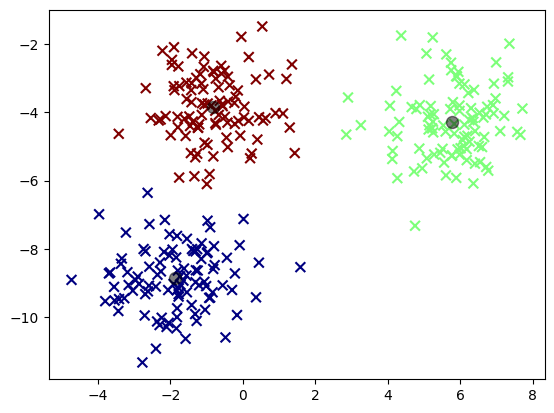

In [10]:
kmeans_sklearn = KMeans(n_clusters=3)
kmeans_sklearn.fit(X1)
y_kmeans = kmeans_sklearn.predict(X1)

plt.scatter(X1[:, 0], X1[:, 1], c=y_kmeans, s=50, cmap='jet', marker='x')
centers = kmeans_sklearn.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=75, alpha=0.5);

print("The silhouette score of this clustering is", silhouette_score(X1, y_kmeans))


The silhouette score of this clustering is 0.6119190460912999


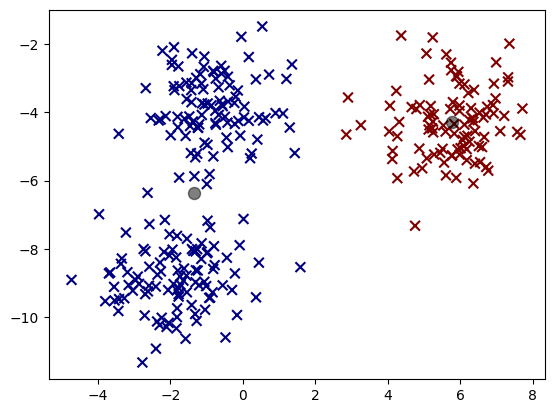

In [11]:
kmeans_sklearn = KMeans(n_clusters=2)
kmeans_sklearn.fit(X1)
y_kmeans = kmeans_sklearn.predict(X1)

plt.scatter(X1[:, 0], X1[:, 1], c=y_kmeans, s=50, cmap='jet', marker='x')
centers = kmeans_sklearn.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=75, alpha=0.5);

print("The silhouette score of this clustering is", silhouette_score(X1, y_kmeans))

The silhouette score of this clustering is 0.33612275830103466


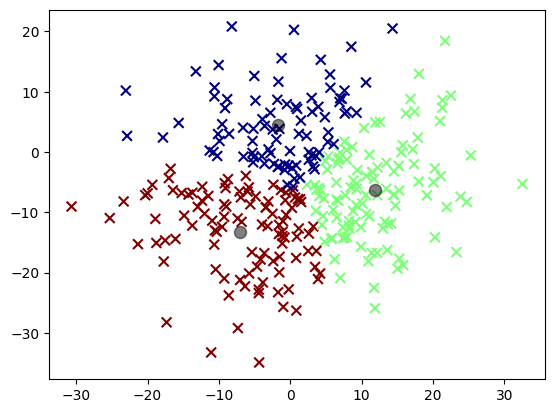

In [12]:
kmeans_sklearn = KMeans(n_clusters=3)
kmeans_sklearn.fit(X2)
y_kmeans = kmeans_sklearn.predict(X2)

plt.scatter(X2[:, 0], X2[:, 1], c=y_kmeans, s=50, cmap='jet', marker='x')
centers = kmeans_sklearn.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=75, alpha=0.5);

print("The silhouette score of this clustering is", silhouette_score(X2, y_kmeans))

The silhouette score of this clustering is -0.024099556741893752


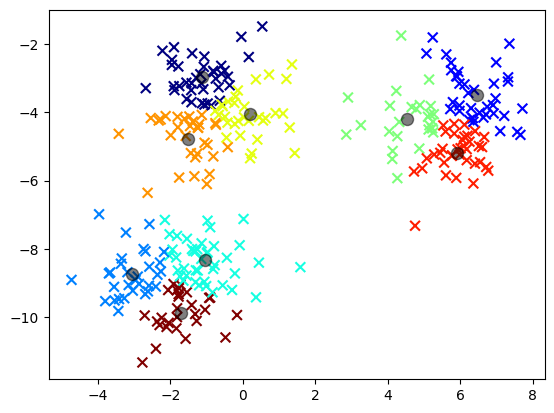

In [13]:
kmeans_sklearn = KMeans(n_clusters=9)
kmeans_sklearn.fit(X1)
y_kmeans = kmeans_sklearn.predict(X1)

plt.scatter(X1[:, 0], X1[:, 1], c=y_kmeans, s=50, cmap='jet', marker='x')
centers = kmeans_sklearn.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=75, alpha=0.5);

print("The silhouette score of this clustering is", silhouette_score(X2, y_kmeans))

### Finding the Number of Clusters: the Elbow Method

One of the most critical aspects of clustering is selecting the correct value of K.

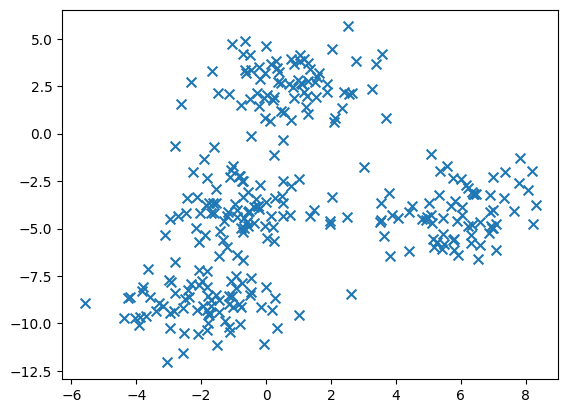

In [14]:
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=1.3, random_state=40)
plt.scatter(X[:, 0], X[:, 1], s=50, marker='x');

Randomly selecting K might not be a favorable choice.

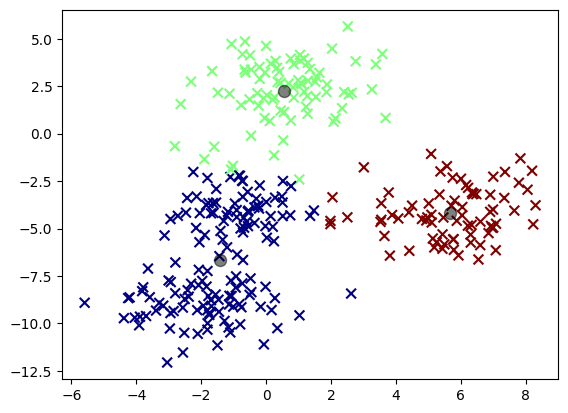

In [15]:
kmeans_sklearn = KMeans(n_clusters=3)
kmeans_sklearn.fit(X)
y_kmeans = kmeans_sklearn.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='jet', marker='x')
centers = kmeans_sklearn.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=75, alpha=0.5);

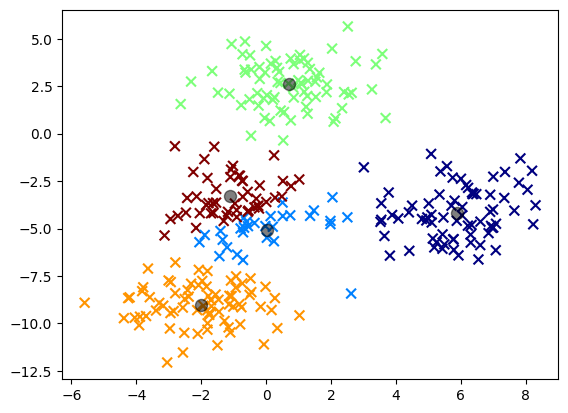

In [16]:
kmeans_sklearn = KMeans(n_clusters=5)
kmeans_sklearn.fit(X)
y_kmeans = kmeans_sklearn.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='jet', marker='x')
centers = kmeans_sklearn.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=75, alpha=0.5);

We can use the elbow method and silhouette score to choose the value of K.


To compare inertia and silhouette scores and determine the optimal number of clusters for the data, you can follow these steps:

1. Loop through a range of cluster numbers (e.g., 2 to 10) and fit the clustering algorithms (KMeans, etc.) for each number of clusters.
2. Calculate and store the inertia and silhouette scores for each clustering model and each number of clusters.
3. Plot the inertia and silhouette scores as a function of the number of clusters.
4. Examine the plots to determine the optimal number of clusters.

> For the inertia plot, look for an "elbow" point, where the rate of decrease in inertia starts to level off.
> For the silhouette plot, look for the highest silhouette score.

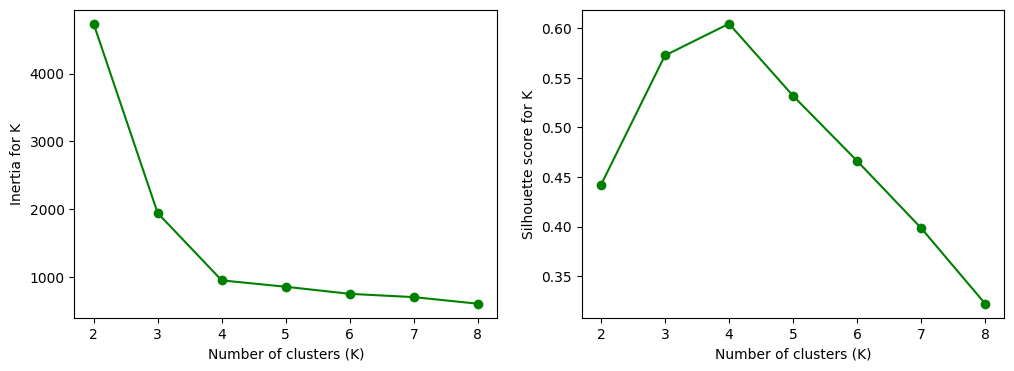

In [17]:
all_inertia = []
all_silhouette_score = []

k_range = list(range(2, 9))
for k in range(2, 9):
  kmeans_sklearn = KMeans(n_clusters=k)
  kmeans_sklearn.fit(X)
  y_kmeans = kmeans_sklearn.predict(X)
  all_inertia.append(kmeans_sklearn.inertia_)
  all_silhouette_score.append(silhouette_score(X, y_kmeans))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=100)
# plt.figure(figsize=(6, 4), dpi=100)
axes[0].plot(k_range, all_inertia, color="green", marker="o")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia for K")
axes[1].plot(k_range, all_silhouette_score, color="green", marker="o")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette score for K")
plt.show()

#### Question: Acccording to the graph, what's a good guess for k? Validate using the cell below
Good guess for k is 4, according to the elbow method 4 is the start where the decrease of inertia score level off and the silhouette score is max.

<!-- 4 -->

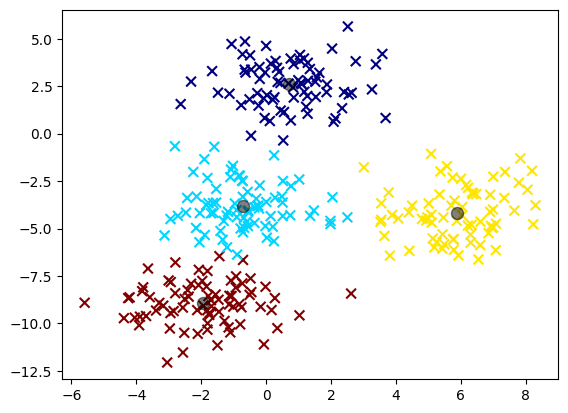

In [18]:
### YOUR ANSWER HERE ###
ANSWER = 4

kmeans_sklearn = KMeans(n_clusters=ANSWER)
kmeans_sklearn.fit(X)
y_kmeans = kmeans_sklearn.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='jet', marker='x')
centers = kmeans_sklearn.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=75, alpha=0.5);

### Trying different algorithms

As you've learned in the lecture, a weakness of K-means is that it cannot deal with non-convex data

<Axes: >

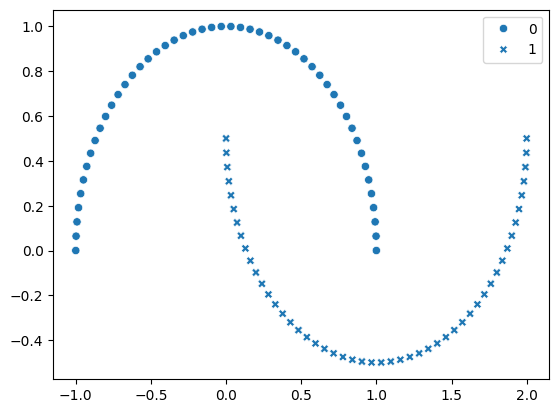

In [19]:
X_moon, y_moon_true = make_moons(n_samples=100, random_state=40)
sns.scatterplot(x=X_moon[:, 0], y=X_moon[:, 1], style=y_moon_true)

Text(0.5, 1.0, 'Markers indicate ground truths, colors indicate predictions')

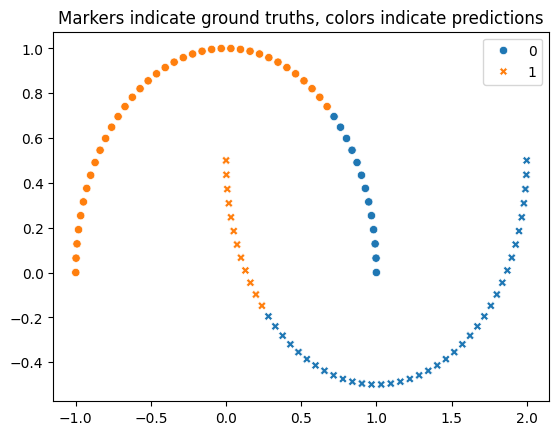

In [20]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(X_moon)
y_kmeans = kmeans.predict(X_moon)
sns.scatterplot(x=X_moon[:, 0], y=X_moon[:, 1], hue=y_kmeans, style=y_moon_true)
plt.title(label='Markers indicate ground truths, colors indicate predictions')

Real-life data is often non-convex. For such cases, we need an algorithm that can discover clusters of any shape, such as DBSCAN

Text(0.5, 1.0, 'Markers indicate ground truths, colors indicate predictions')

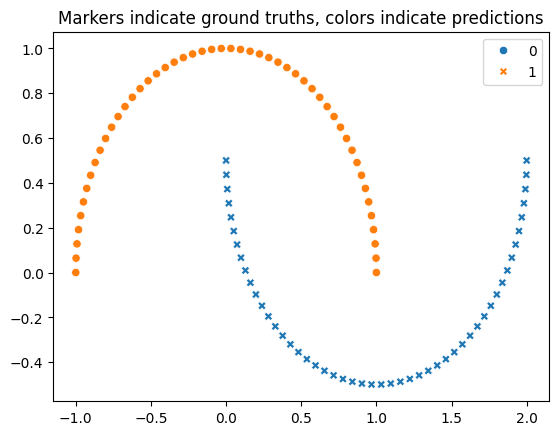

In [21]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan.fit(X_moon)
y_dbscan = dbscan.labels_
sns.scatterplot(x=X_moon[:, 0], y=X_moon[:, 1], hue=y_dbscan, style=y_moon_true)
plt.title(label='Markers indicate ground truths, colors indicate predictions')

#### Question: So is it ever worth using KMeans over DBSCAN? 
Yes since KMeans is much faster than DBSCAN
Hint: look at the cell below.

<!-- **Yes!** KMeans is much faster than DBSCAN: -->

In [22]:
big_blobs = make_blobs(n_samples=30000, centers=3, cluster_std=1.0, random_state=40)
X_big, y_big_true = big_blobs

start = time.time()
kmeans = KMeans(n_clusters=3)
kmeans.fit(X_big)
y_kmeans = kmeans.predict(X_big)
end = time.time()
print("Time taken for KMeans on 30,000 samples is", end - start, "seconds")
kmeans_score = silhouette_score(X_big, y_kmeans)
print("The silhouette score of this clustering is", kmeans_score)

start = time.time()
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(X_big)
y_dbscan = dbscan.labels_
end = time.time()
print("Time taken for DBSCAN on 30,000 samples is", end - start, "seconds")
dbscan_score = silhouette_score(X_big, y_dbscan)
print("The silhouette score of this clustering is", dbscan_score)

Time taken for KMeans on 30,000 samples is 0.024477720260620117 seconds
The silhouette score of this clustering is 0.676076083002287
Time taken for DBSCAN on 30,000 samples is 1.2006580829620361 seconds
The silhouette score of this clustering is 0.21268754311995666


## Part 2. Tackling a real-life dataset

For this next section, we'll be working with the [Wholesale customers](https://archive.ics.uci.edu/dataset/292/wholesale+customers) dataset

In [23]:
# !curl -OL https://archive.ics.uci.edu/static/public/292/wholesale+customers.zip
# !tar -xvf wholesale+customers.zip

In [24]:
import pandas as pd
df = pd.read_csv("Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


Using any clustering algorithm you'd like, perform hyperparameter tuning, then report the best result you found using inertia and silhouette score as metrics.

For K = 2 the cluster distribution is {np.int32(0): np.int64(65), np.int32(1): np.int64(375)}
For K = 3 the cluster distribution is {np.int32(0): np.int64(337), np.int32(1): np.int64(75), np.int32(2): np.int64(28)}
For K = 4 the cluster distribution is {np.int32(0): np.int64(283), np.int32(1): np.int64(59), np.int32(2): np.int64(91), np.int32(3): np.int64(7)}
For K = 5 the cluster distribution is {np.int32(0): np.int64(196), np.int32(1): np.int64(50), np.int32(2): np.int64(49), np.int32(3): np.int64(138), np.int32(4): np.int64(7)}
For K = 6 the cluster distribution is {np.int32(0): np.int64(37), np.int32(1): np.int64(210), np.int32(2): np.int64(64), np.int32(3): np.int64(5), np.int32(4): np.int64(8), np.int32(5): np.int64(116)}
For K = 7 the cluster distribution is {np.int32(0): np.int64(206), np.int32(1): np.int64(105), np.int32(2): np.int64(17), np.int32(3): np.int64(84), np.int32(4): np.int64(22), np.int32(5): np.int64(4), np.int32(6): np.int64(2)}
For K = 8 the cluster distribution

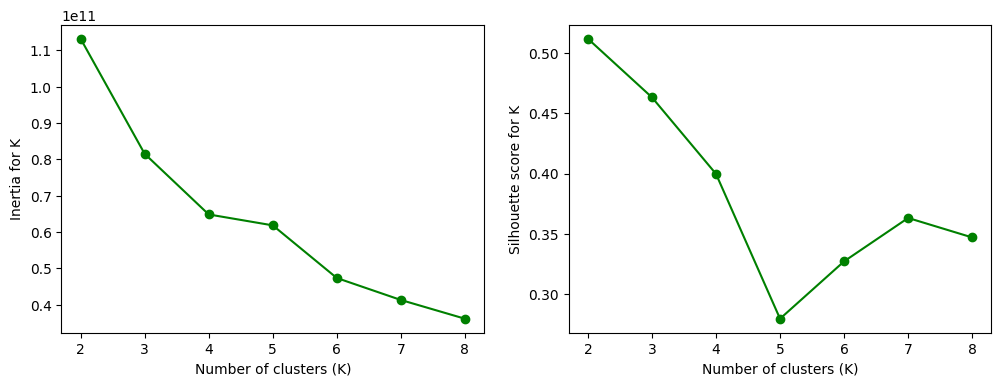

In [28]:
all_inertia = []
all_silhouette_score = []
all_cluster_distributions = []
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df)
    y_kmeans = kmeans.predict(df)
    all_inertia.append(kmeans.inertia_)
    all_silhouette_score.append(silhouette_score(df, y_kmeans))
    clusters, cluster_distribution = np.unique(y_kmeans, return_counts=True)
    print("For K =", k, "the cluster distribution is", dict(zip(clusters, cluster_distribution)))
    all_cluster_distributions.append(cluster_distribution)
# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=100)
axes[0].plot(range(2, 9), all_inertia, color="green", marker="o")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia for K")
axes[1].plot(range(2, 9), all_silhouette_score, color="green", marker="o")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette score for K")
plt.show()

## I think that 7 is the optimal point since from that the inertia start to level off and silhoutte is one of the highest